# 单分子器件数据PCA降维与聚类分析
本notebook实现简洁的PCA降维和K-means聚类分析，生成三合一可视化图表

In [26]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 设置图形参数
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [27]:
# 加载数据
dataset_name = 'C4'
data = np.load(f'datas/{dataset_name}.npz')
conductance_array = data['conductance_array']
distance_array = data['distance_array']

print(f"Data shape: {conductance_array.shape}")
print(f"Total traces: {len(conductance_array)}")

Data shape: (1963, 400)
Total traces: 1963


In [28]:
# 数据预处理：标准化
scaler = StandardScaler()
conductances_scaled = scaler.fit_transform(conductance_array)

# PCA降维到2维
pca = PCA(n_components=2)
conductances_pca = pca.fit_transform(conductances_scaled)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {sum(pca.explained_variance_ratio_):.4f}")

PCA explained variance ratio: [0.63423681 0.11107883]
Total explained variance: 0.7453


In [29]:
# K-means聚类 (2类)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(conductances_pca)

# 获取两个聚类的数据
cluster_0_indices = cluster_labels == 0
cluster_1_indices = cluster_labels == 1

cluster_0_traces = conductance_array[cluster_0_indices]
cluster_1_traces = conductance_array[cluster_1_indices]

print(f"Cluster 0: {len(cluster_0_traces)} traces")
print(f"Cluster 1: {len(cluster_1_traces)} traces")

Cluster 0: 795 traces
Cluster 1: 1168 traces


In [30]:
# 计算平均轨迹
mean_trace_0 = cluster_0_traces.mean(axis=0)
mean_trace_1 = cluster_1_traces.mean(axis=0)
std_trace_0 = cluster_0_traces.std(axis=0)
std_trace_1 = cluster_1_traces.std(axis=0)

# 使用第一个轨迹的distance作为x轴
distance = distance_array[0]

print(f"Cluster 0 mean conductance: {mean_trace_0.mean():.6f} G0")
print(f"Cluster 1 mean conductance: {mean_trace_1.mean():.6f} G0")

Cluster 0 mean conductance: -1.042568 G0
Cluster 1 mean conductance: 0.652295 G0


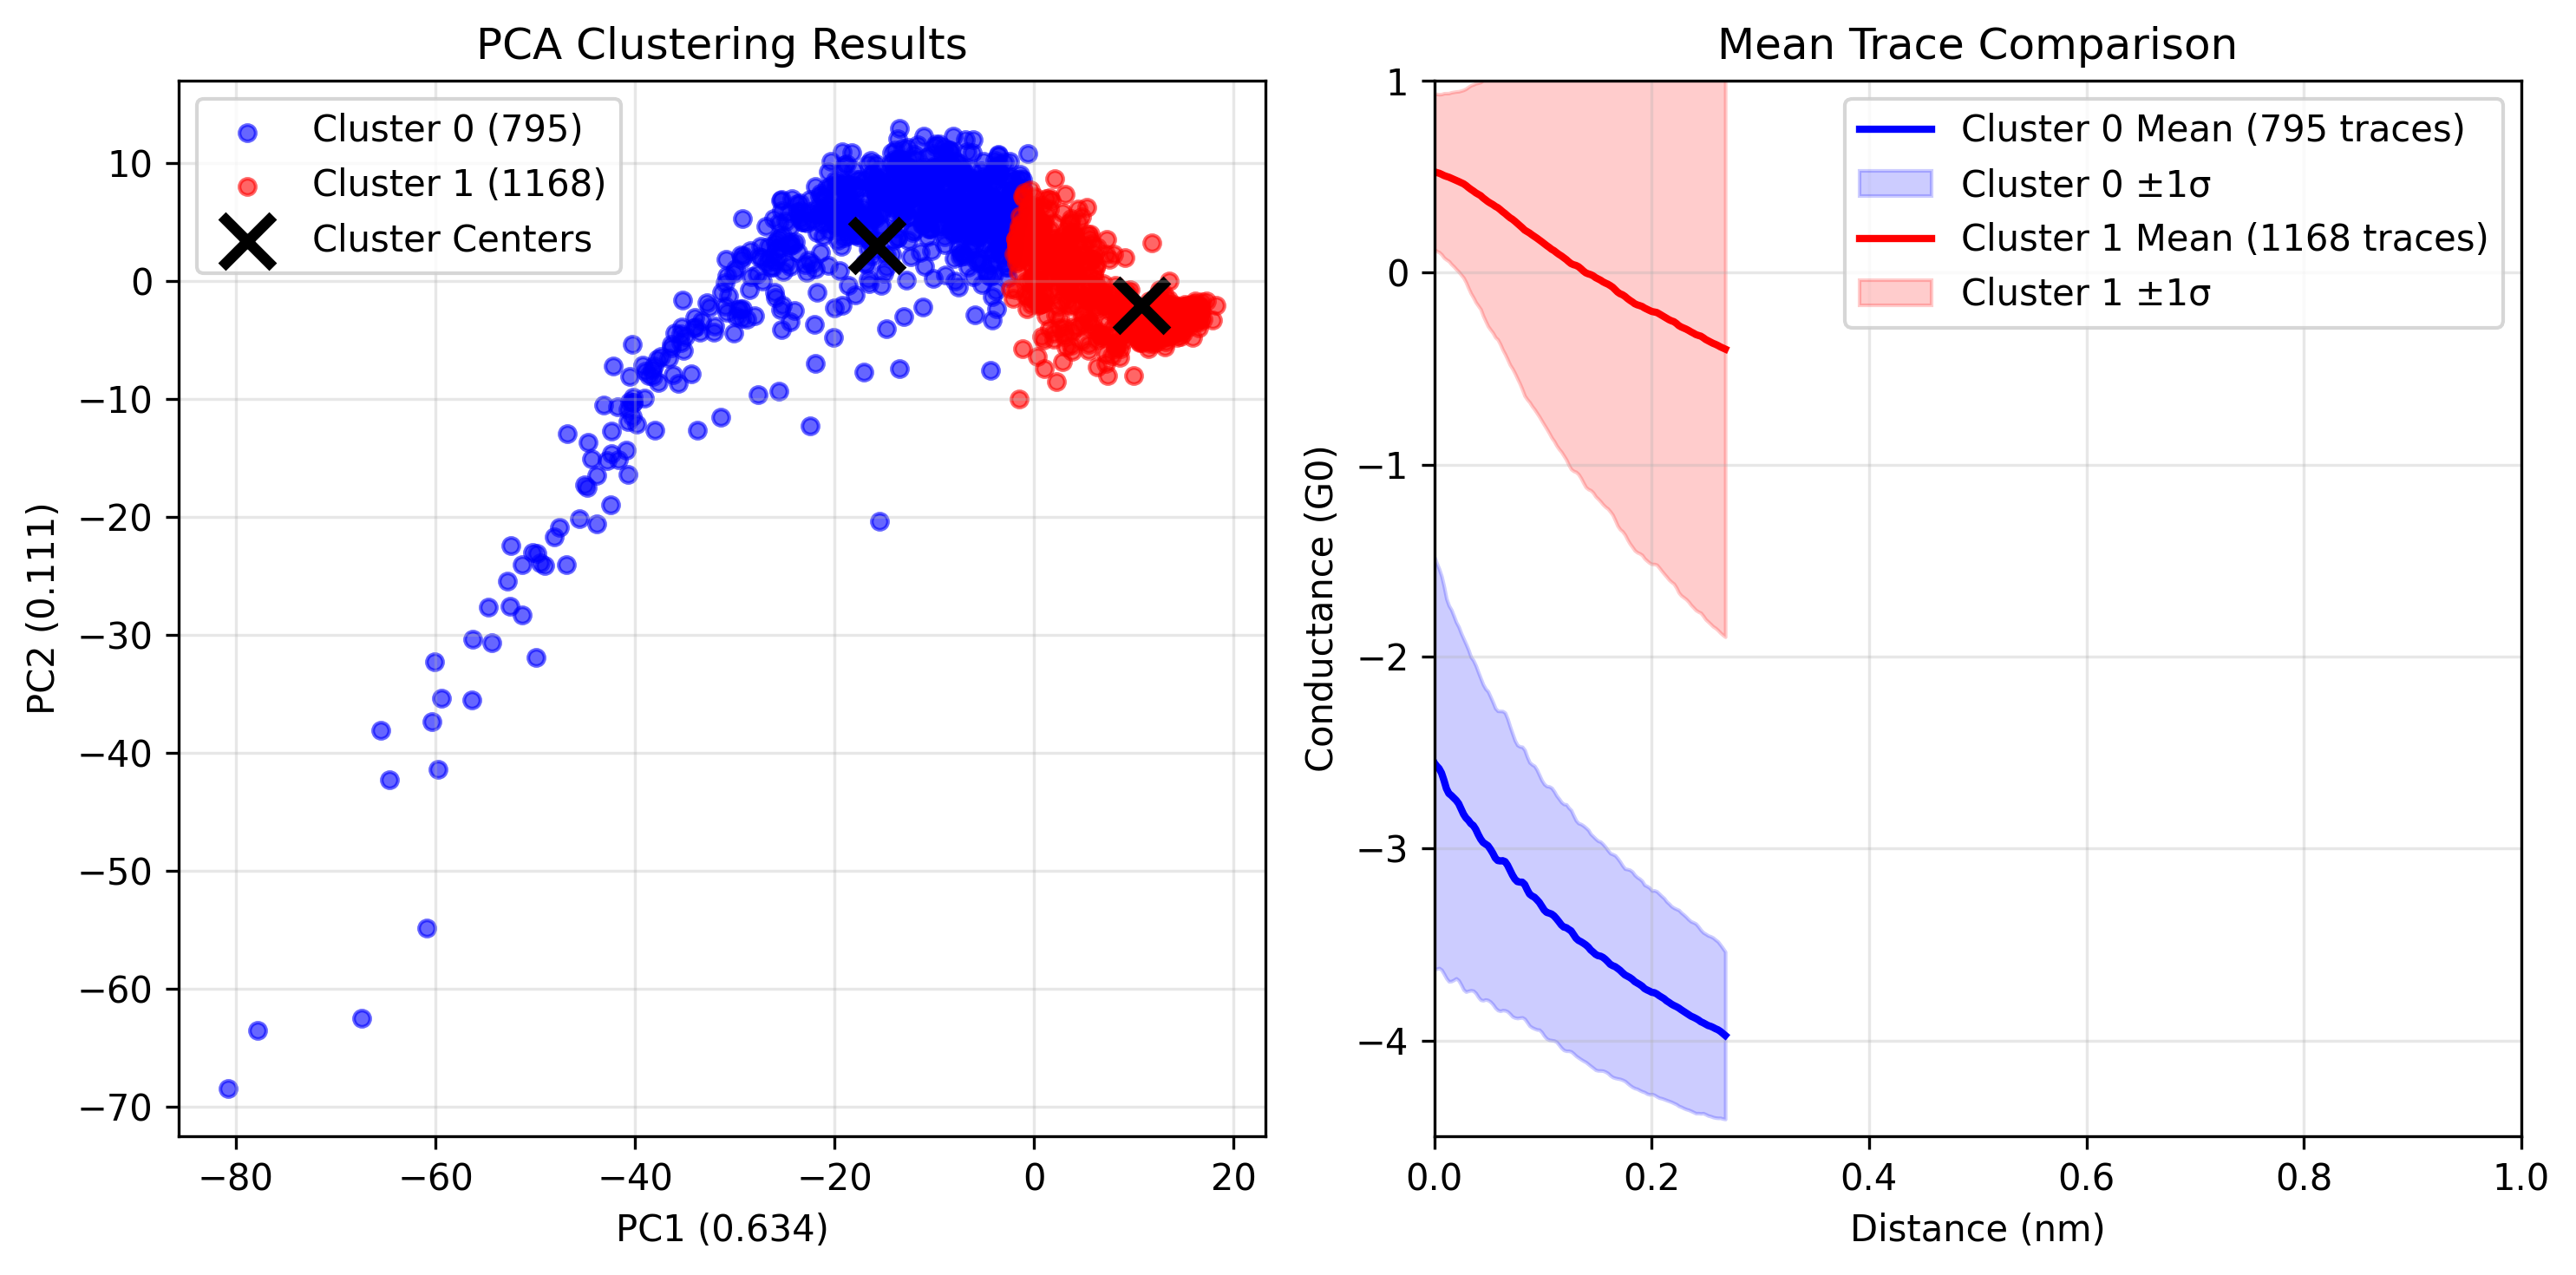


Result saved as 'C4_result.png'


In [ ]:
# 创建二合一图表：左-散点图，右-两类平均轨迹对比
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 左图：PCA聚类散点图
scatter = axes[0].scatter(conductances_pca[cluster_0_indices, 0], 
                         conductances_pca[cluster_0_indices, 1], 
                         c='blue', alpha=0.6, s=20, label=f'Cluster 0 ({len(cluster_0_traces)})')
axes[0].scatter(conductances_pca[cluster_1_indices, 0], 
               conductances_pca[cluster_1_indices, 1], 
               c='red', alpha=0.6, s=20, label=f'Cluster 1 ({len(cluster_1_traces)})')

# 添加聚类中心
centers = kmeans.cluster_centers_
axes[0].scatter(centers[:, 0], centers[:, 1], 
               c='black', marker='x', s=200, linewidths=3, label='Cluster Centers')

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.3f})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.3f})')
axes[0].set_title('PCA Clustering Results')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图：两类平均轨迹对比
axes[1].plot(distance, mean_trace_0, color='blue', linewidth=2, 
            label=f'Cluster 0 Mean ({len(cluster_0_traces)} traces)')
axes[1].fill_between(distance, 
                    mean_trace_0 - std_trace_0, 
                    mean_trace_0 + std_trace_0, 
                    alpha=0.2, color='blue', label='Cluster 0 ±1σ')

axes[1].plot(distance, mean_trace_1, color='red', linewidth=2, 
            label=f'Cluster 1 Mean ({len(cluster_1_traces)} traces)')
axes[1].fill_between(distance, 
                    mean_trace_1 - std_trace_1, 
                    mean_trace_1 + std_trace_1, 
                    alpha=0.2, color='red', label='Cluster 1 ±1σ')

axes[1].set_xlabel('Distance (nm)')
axes[1].set_ylabel('Conductance (G0)')
axes[1].set_title('Mean Trace Comparison')
axes[1].set_xlim(0, max(distance))
axes[1].set_ylim(-4.5, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{dataset_name}_result.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nResult saved as '{dataset_name}_result.png'")